In [13]:
# 일원분산(ANOVA) 분석


In [14]:
import pandas as pd
df = pd.read_csv("datas2/지점별_일별판매량.csv", encoding='euc-kr')
df.head()

A = df['지점A'].dropna().values
B = df['지점B'].dropna().values
C = df['지점C'].dropna().values

# matplotlib 한글 폰트 설정 방법
# sudo apt update
# sudo apt install fonts-nanum
# fc-list | grep Nanum

# 그래도 폰트가 계속 깨진다면 아래 명령어 실행하기 
# rm -rf ~/.cache/matplotlib

# 박스플롯으로 시각화

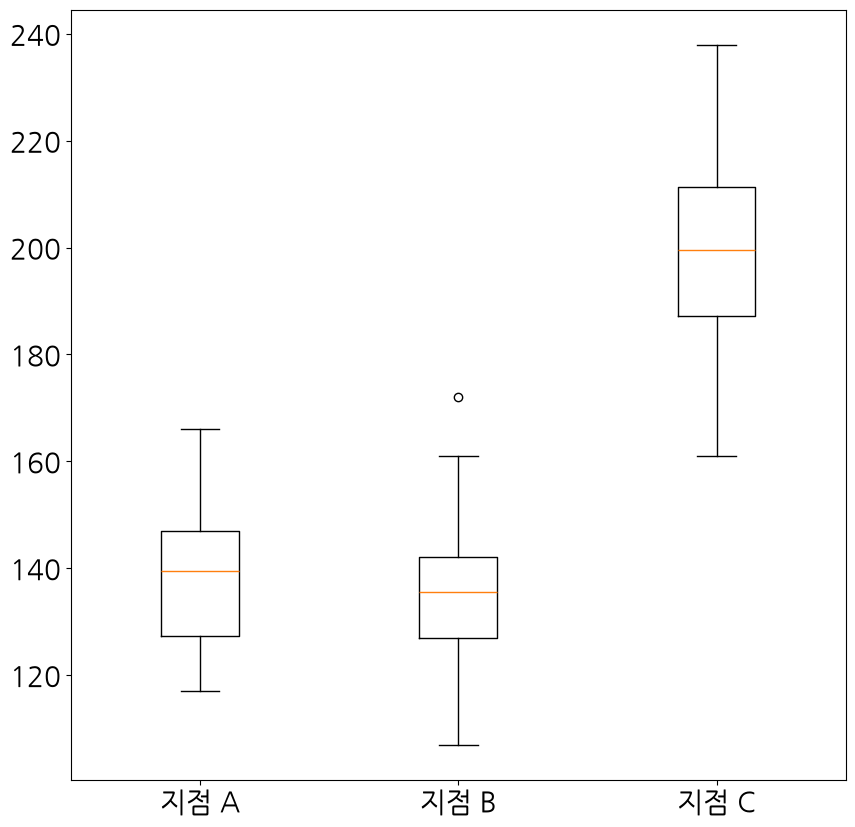

In [15]:
from matplotlib import pyplot as plt
#plt.rcParams["font.family"] = 'Malgun Gothic'  # 윈도우
plt.rcParams['font.family'] = 'NanumGothic'      # 우분투
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["font.size"] = 20
plt.rcParams["figure.figsize"] = (10, 10)
plt.boxplot([A, B, C])
plt.xticks([1, 2, 3], ['지점 A', '지점 B', '지점 C'])
plt.show()

# 3가지 데이터에 대한 정규성 검정
p > 0.05 → 귀무가설 기각 못함 → 정규성으로 판단
p ≤ 0.05 → 귀무가설 기각 → 정규성이 아니라고 판단

In [16]:

from scipy import stats
print(stats.shapiro(A-B))
print(stats.shapiro(A-C))
print(stats.shapiro(B-C))

ShapiroResult(statistic=np.float64(0.9806113783329989), pvalue=np.float64(0.8415709869849196))
ShapiroResult(statistic=np.float64(0.9756594682818899), pvalue=np.float64(0.7021590567772881))
ShapiroResult(statistic=np.float64(0.9766118847905252), pvalue=np.float64(0.7301124192407404))


# 3 지점의 등분산선 검정 (서로 비슷한 느낌으로 분산되어있는지 확인)
p > 0.05 → 귀무가설 기각 못함 → 등분산으로 판단
p ≤ 0.05 → 귀무가설 기각 → 등분산이 아니라고 판단

In [17]:
levene_stat, levene_p_value = stats.levene(A, B, C, center='median') 
# median 으로 한이유는 이상치에 휘둘리지 않기위해서, 방법은 다양하며 결국 사용할 데이터를 보고 어느정도 먼저 결정해야하는걸지도
print(f"levene_stat: {levene_stat}, levene_p_value: {levene_p_value}")
#0.29 임으로 등분산


print(stats.f_oneway(A, B, C))
#f_oneway 는 3가지 집단의 평균이 서로 같은지 다른지를 검정

#pvalue 1.6~-31임으로 대립가설, '무언가, 1개이상'의 평균이 다르다

levene_stat: 1.244640322359082, levene_p_value: 0.2931218868935262
F_onewayResult(statistic=np.float64(178.43825416847133), pvalue=np.float64(1.633742028566481e-31))


# ANOVA 코드, (stats.f_oneway(A,B,C)) 는 기본적으로 '각그룹의 평균이 같다' 란 것을 전제로 하는 기능이며 반대로 다르다를 전제로하는 기능은 통계적 원칙상 없다.(그렇다고 이해해야함)

즉 A B C 중에서 하나라도 서로 다르다는 것만 알아냄, 이후에는 뭐가 다른건지를 찾아야할 필요가있음

In [18]:

from statsmodels.stats import multicomp 

# 분석 대상 데이터
Data = A.tolist() + B.tolist() + C.tolist()
# 각 값이 속한 그룹 이름
Group = ['A'] * len(A) + ['B'] * len(B) + ['C'] * len(C)

print(Data)
print(Group)

# 사후 분석
print(multicomp.pairwise_tukeyhsd(Data, Group))

[124, 147, 129, 123, 147, 149, 140, 142, 124, 166, 127, 130, 139, 121, 149, 155, 140, 150, 137, 144, 136, 126, 150, 142, 149, 127, 140, 138, 128, 117, 118, 141, 130, 127, 107, 140, 146, 122, 160, 157, 141, 142, 150, 136, 157, 107, 172, 126, 135, 115, 133, 132, 127, 128, 142, 161, 140, 125, 142, 135, 216, 214, 212, 179, 222, 238, 218, 200, 186, 188, 216, 183, 198, 199, 187, 183, 190, 161, 203, 192, 235, 208, 187, 201, 196, 202, 209, 179, 197, 204]
['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    uppe